PASO 5.1| FEATURE ENGINEERING.

--------------------------------

NUESTRO MEJOR ALIADO PARA CAPTURAR UNA MEJOR CORRELACION LINEAL Y NO LINEAL ENTRE VARIABLES Y VARIABLE TARGET
ES ENTENDER LAS POSIBILIDADES QUE OFRECEN LOS DATOS DE LAS DIFRENTES DISTRIBUCIONES DE LAS VARIABLES
Y LAS CORRELACIONES LINEALES ENTRE VARIABLES GRACIAS AL MAPA DE CALOR.

SE TRATA DE VISUALIZAR CUANDO UNA DISTRIBUCION ES POSIBLE DERIVARLA EN DOS DADO SU SEGREGACION EN DOS O MAS GRANDES GRUPOS DE MUESTRAS.

TAMBIEN SE TRATA DE ENTENDER QUE CUANDO UNA VARIABLE TIENE MUCHA CORRELACION ENTRE OTRAS SE PUEDEN COMBINAR, INCLUSIO HACER MEDIAS ARITMETICAS Y SENSIBILIZAR LA VARIABLE PRODUCTO CAMBIANDOLA DE DISCRETA A CONTINUA.
BINARIZAR TAMBIEN ES UNA OPCION.

INCLUSO PASAR DE UNA VARIABLE CONTINUA A DISCONTINUA SI SU CORRELACION ES BAJA PARA CAPTURAR OTRAS CORRELACIONES NO LINEALES.

In [1]:
import numpy as np, random
import pandas as pd

In [2]:
df = pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/dfeda.csv')


In [3]:
#Empezamos por binarizacion:
#Observamos distribuciones y variables con poca linealidad.
#Si es simetrica gaussiana se hace un cut, si es simetrica muy desplazada se binariza, ponderizando
#en funcion del diferencial de muestras de los dos primeros cuartiles respecto a los dos ultimos.
import pandas as pd

def factorizar_religiosidad(df, columna='rlgdgr'):

  
    def asignar_categoria(x):
        if x <= 3.9:
            return 0  # ateo
        elif 4 <= x <= 6:
            return 1  # escéptico
        else:
            return 2  # creyente

    df['rel3fc'] = df[columna].apply(asignar_categoria)
    return df

# Ejemplo de uso:
df = factorizar_religiosidad(df)
print(df['rel3fc'].value_counts())


rel3fc
0    21856
2    20728
1    20080
Name: count, dtype: int64


In [4]:
print(df['happy'].value_counts())

happy
8.0     17624
7.0     12901
9.0      8743
6.0      6529
5.0      6375
10.0     5387
4.0      2076
3.0      1621
2.0       754
0.0       332
1.0       322
Name: count, dtype: int64


In [5]:
#18-'happy': Escala de 0 a 10, grado de cuan feliz eres, siendo 0 infeliz.
#Apenas tiene linealidad +/- vamos a derivarla en dos nuevas variables. A ver si capturamos correlaciones
# unhappybin y happybin
def pondbin(df, columna='happy'):

    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)

    def asignar_categoria(x):
        if x < q1:
            return 'bajo'
        elif x > q3:
            return 'alto'
        else:  # q1 <= x <= q3
            if x == 5:
                if abs(5 - q1) < abs(5 - q3):
                    return 'bajo'  # Ponderar hacia 'bajo'
                else:
                    return 'alto'  # Ponderar hacia 'alto'
            else:
                return 'medio'

    df['happyfc'] = df[columna].apply(asignar_categoria)
    return df
df = pondbin(df)
print(df['happyfc'].value_counts())


happyfc
medio    37054
alto     14130
bajo     11480
Name: count, dtype: int64


In [6]:
dicthappy = {
    'bajo': '0',
    'medio': '1',
    'alto': '2',
}
df['happyfc'] = df['happyfc'].map(dicthappy)
print(df['happyfc'].value_counts())

happyfc
1    37054
2    14130
0    11480
Name: count, dtype: int64


In [7]:

def escalacontinuamedia(df):
    columnas_confianza = [
        'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trtsci_pnd'
    ]

    df['confianza_promedio'] = df[columnas_confianza].mean(axis=1)
    return df

df = escalacontinuamedia(df)
print(df['confianza_promedio'].describe())

count    62664.000000
mean         4.808589
std          1.722607
min          0.000000
25%          3.571429
50%          4.857143
75%          6.000000
max         10.000000
Name: confianza_promedio, dtype: float64


In [8]:

import pandas as pd
def cutcontinua(df, columna, bins):
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    if bins <= 0:
        raise ValueError("El número de bins debe ser mayor que 0.")

    labels = list(range(bins))  # Etiquetas numéricas (0, 1, 2, ...)
    df[columna + '_factorizada'] = pd.cut(df[columna], bins=bins, labels=labels, right=False)
    return df

df = cutcontinua(df, 'confianza_promedio', bins=5)
print(df['confianza_promedio_factorizada'].value_counts())

confianza_promedio_factorizada
2    25970
1    15874
3    15867
0     3442
4     1511
Name: count, dtype: int64


In [9]:
def escalacontinuamedia(df):
    columnas_satisfecho = [
        'stfgov', 'stfeco', 'stfdem',
    ]

    df['satisf_media'] = df[columnas_satisfecho].mean(axis=1)
    return df

df = escalacontinuamedia(df)
print(df['satisf_media'].describe())

count    62664.000000
mean         4.474174
std          2.058423
min          0.000000
25%          3.000000
50%          4.666667
75%          6.000000
max         10.000000
Name: satisf_media, dtype: float64


In [10]:
def cutcontinua(df, columna, bins):
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    if bins <= 0:
        raise ValueError("El número de bins debe ser mayor que 0.")

    labels = list(range(bins))  # Etiquetas numéricas (0, 1, 2, ...)
    df[columna + '_factorizada'] = pd.cut(df[columna], bins=bins, labels=labels, right=False)
    return df

df = cutcontinua(df, 'satisf_media', bins=5)
print(df['satisf_media_factorizada'].value_counts())

satisf_media_factorizada
2    21987
1    15527
3    15325
0     7515
4     2310
Name: count, dtype: int64


In [11]:
def pondbin(df, columna):

    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)

    def asignar_categoria(x):
        if x < q1:
            return 'bajo'
        elif x > q3:
            return 'alto'
        else:  # q1 <= x <= q3
            if x == 5:
                if abs(5 - q1) < abs(5 - q3):
                    return 'bajo'  # Ponderar hacia 'bajo'
                else:
                    return 'alto'  # Ponderar hacia 'alto'
            else:
                return 'medio'

    df['pintfc'] = df[columna].apply(asignar_categoria)
    return df
df = pondbin(df, 'polintr')
print(df['pintfc'].value_counts())

pintfc
medio    45563
alto     10542
bajo      6559
Name: count, dtype: int64


In [12]:
dictint = {
    'bajo': '0',
    'medio': '1',
    'alto': '2',
}
df['pintfc'] = df['pintfc'].map(dicthappy)
print(df['pintfc'].value_counts())

pintfc
1    45563
2    10542
0     6559
Name: count, dtype: int64


In [13]:
def escalacontinuamedia(df):
    columnas_gente= [
        'pplfair', 'pplhlp', 'ppltrst',
    ]

    df['ppl'] = df[columnas_gente].mean(axis=1)
    return df

df = escalacontinuamedia(df)
print(df['ppl'].describe())

count    62664.000000
mean         4.911821
std          1.867852
min          0.000000
25%          3.666667
50%          5.000000
75%          6.333333
max         10.000000
Name: ppl, dtype: float64


In [14]:
def cutcontinua(df, columna, bins):
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    if bins <= 0:
        raise ValueError("El número de bins debe ser mayor que 0.")

    labels = list(range(bins))  # Etiquetas numéricas (0, 1, 2, ...)
    df[columna + '_fc'] = pd.cut(df[columna], bins=bins, labels=labels, right=False)
    return df

df = cutcontinua(df, 'ppl', bins=4)
print(df['ppl_fc'].value_counts())

ppl_fc
2    30196
1    21361
0     6830
3     4277
Name: count, dtype: int64


In [15]:
def cutcontinua(df, columna, bins):
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    if bins <= 0:
        raise ValueError("El número de bins debe ser mayor que 0.")

    labels = list(range(bins))  # Etiquetas numéricas (0, 1, 2, ...)
    df[columna + '_fc'] = pd.cut(df[columna], bins=bins, labels=labels, right=False)
    return df

df = cutcontinua(df, 'lrscale', bins=4)
print(df['lrscale_fc'].value_counts())

lrscale_fc
2    31804
1    13564
3     8660
0     8636
Name: count, dtype: int64


In [16]:
def cutcontinua(df, columna, bins):
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    if bins <= 0:
        raise ValueError("El número de bins debe ser mayor que 0.")

    labels = list(range(bins))  # Etiquetas numéricas (0, 1, 2, ...)
    df[columna + '2_fc'] = pd.cut(df[columna], bins=bins, labels=labels, right=False)
    return df

df = cutcontinua(df, 'lrscale', bins=5)
print(df['lrscale2_fc'].value_counts())

lrscale2_fc
2    26214
3    12250
1    11133
4     8660
0     4407
Name: count, dtype: int64


df1.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/models/presplit.csv', index=False)

Vamos a transformar variables de escala ordinarias 0 a 10 en variables categoricas factorizadas de 3 clases.
Utilizaremos basicamente dos funciones. Tendremos que observar el grafico de las distribuciones de cada variable a 
transformar para escoger una de las dos.
La primera es cuando la funcion normal esta expandida, es decir las muestras estan dispersas por todos los cuartiles.
La segunda se utilizara cuando la funcion tiene el pico absoluto muy definido, no hace falta que este centrada, las ponderizaciones se calibran para tener en cuenta la ubicacion de la densidad de muestras.

In [17]:
import pandas as pd
import numpy as np

def ord10to3NoMidense(df, columna, nombre_categoria):


    
    percentil_33 = np.percentile(df[columna], 33.3)
    percentil_66 = np.percentile(df[columna], 66.6)

    
    df[nombre_categoria] = pd.cut(df[columna],
                                  bins=[-float('inf'), percentil_33, percentil_66, float('inf')],
                                  labels=[0, 1, 3],
                                  right=True,
                                  include_lowest=True)
    return df

In [18]:
import numpy as np
import pandas as pd

def ord10to3MidDense(df, columna, nombre_nueva_columna):

    serie = df[columna]

    # 1. Calcular cuartiles
    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50)
    q3 = serie.quantile(0.75)

    # 2. Calcular densidad en el punto medio
    densidad_q2 = serie.between(q2 - 0.5, q2 + 0.5).mean()  # Ajusta el rango según sea necesario

    # 3. Calcular proporciones
    proporcion_primeros_cuartiles = serie[serie <= q2].count() / serie.count()
    proporcion_ultimos_cuartiles = serie[serie >= q2].count() / serie.count()

    def asignar_categoria(valor):
        if valor < q1:
            return 0  # Categoría inferior
        elif valor > q3:
            return 2  # Categoría superior
        else:  # Valor cerca del punto medio
            if np.random.rand() < densidad_q2:
                return 1  # Categoría central
            else:
                if np.random.rand() < proporcion_primeros_cuartiles / (proporcion_primeros_cuartiles + proporcion_ultimos_cuartiles):
                    return 0
                else:
                    return 2

    df[nombre_nueva_columna] = serie.apply(asignar_categoria)
    return df


df = ord10to3MidDense(df, 'lrscale', 'lrfc3d')
print(df['lrfc3d'].value_counts())

lrfc3d
0    26699
2    25881
1    10084
Name: count, dtype: int64


Seguimos en otro documento para tantear en diferentes modelos.

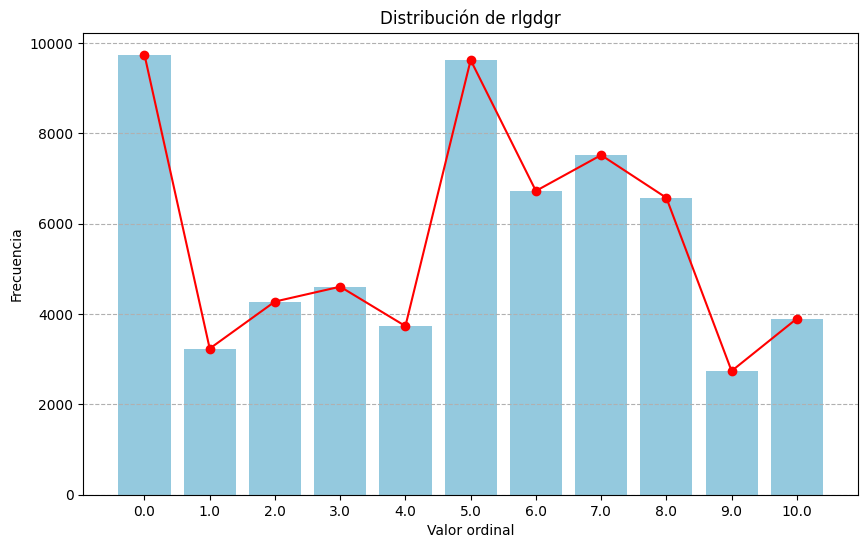

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visdist(df, columna):

    
    frecuencias = df[columna].value_counts().sort_index()

   
    plt.figure(figsize=(10, 6))
    sns.barplot(x=frecuencias.index, y=frecuencias.values, color='skyblue')
    plt.plot(frecuencias.index, frecuencias.values, marker='o', color='red')

    # Añadir etiquetas y título
    plt.xlabel('Valor ordinal')
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {columna}')
    plt.xticks(frecuencias.index)  
    plt.grid(axis='y', linestyle='--')

    # Mostrar el gráfico
    plt.show()


visdist(df, 'rlgdgr')

In [20]:
import numpy as np
import pandas as pd

def binarizar_ponderado(df, columna, nombre_nueva_columna):


    serie = df[columna]

    # Calcular percentiles 25 y 75
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    # Calcular densidades de los rangos mínimo y máximo
    densidad_min = serie[serie < q1].count() / serie.count()
    densidad_max = serie[serie > q3].count() / serie.count()

    def asignar_binario(valor):
        if valor < q1:
            if np.random.rand() < densidad_min:
                return 0
            else:
                return 1
        elif valor > q3:
            if np.random.rand() < densidad_max:
                return 1
            else:
                return 0
        else:
            return 1  # Valor en el rango intermedio (se asigna a 1 por defecto)

    df[nombre_nueva_columna] = serie.apply(asignar_binario)
    return df


df = binarizar_ponderado(df, 'rlgdgr', 'relbin')
print(df['relbin'].value_counts())

relbin
1    49547
0    13117
Name: count, dtype: int64


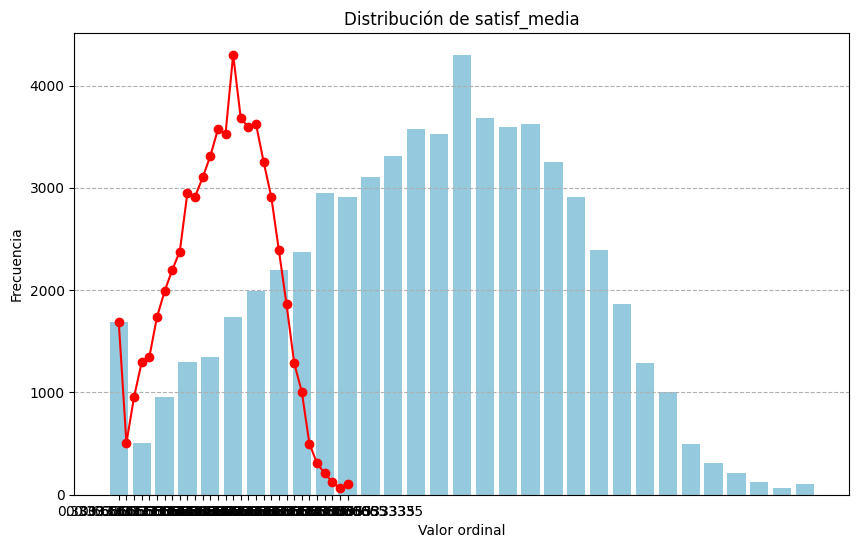

In [21]:
visdist(df, 'satisf_media')

In [22]:
df = ord10to3MidDense(df, 'satisf_media', 'sm3d')

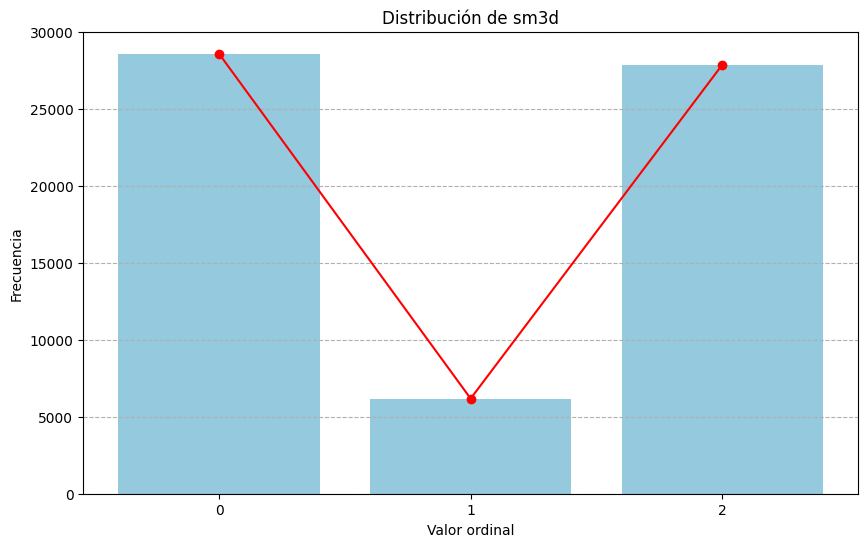

In [23]:
visdist(df, 'sm3d')

In [24]:
def ord10to4MidDense(df, columna, nombre_nueva_columna):
    serie = df[columna]
    # Calcular terciles
    t1 = serie.quantile(1/3)
    t2 = serie.quantile(2/3)

    # Calcular densidad en el punto medio
    densidad_medio = serie.between(t1, t2).mean()

    def asignar_categoria(valor):
        if valor < t1:
            return 0  # Categoría inferior
        elif valor > t2:
            return 3  # Categoría superior
        else:  # Valor cerca del punto medio
            if np.random.rand() < densidad_medio:
                return 1  # Categoría central inferior
            else:
                return 2  # Categoría central superior

    df[nombre_nueva_columna] = serie.apply(asignar_categoria)
    return df
ord10to4MidDense(df,'satisf_media','sm4d')

,cntry,pplfair,pplhlp,ppltrst,lrscale,polintr,stfdem,stfeco,stfgov,trstep,...,satisf_media_factorizada,pintfc,ppl,ppl_fc,lrscale_fc,lrscale2_fc,lrfc3d,relbin,sm3d,sm4d
0,Bélgica,4.0,5.0,5.0,5.0,2.0,7.0,5.0,5.0,5.0,...,2,1,4.666667,1,2,2,1,1,0,2
1,Bélgica,8.0,8.0,10.0,5.0,4.0,5.0,7.0,5.0,2.0,...,2,2,8.666667,3,2,2,0,1,2,2
2,Bélgica,7.0,8.0,7.0,5.0,3.0,6.0,6.0,4.0,7.0,...,2,1,7.333333,2,2,2,2,1,0,2
3,Bélgica,3.0,8.0,0.0,6.0,2.0,7.0,5.0,5.0,7.0,...,2,1,3.666667,1,2,3,2,1,2,2
4,Bélgica,5.0,8.0,6.0,8.0,2.0,9.0,8.0,4.0,8.0,...,3,1,6.333333,2,3,4,2,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62659,Eslovaquia,3.0,4.0,2.0,3.0,2.0,4.0,3.0,3.0,3.0,...,1,1,3.000000,1,1,1,0,0,2,0
62660,Eslovaquia,8.0,8.0,4.0,2.0,3.0,2.0,2.0,2.0,8.0,...,1,1,6.666667,2,0,1,0,1,0,0
62661,Eslovaquia,5.0,5.0,5.0,7.0,1.0,5.0,3.0,5.0,9.0,...,2,0,5.000000,2,2,3,2,0,0,2
62662,Eslovaquia,7.0,4.0,7.0,0.0,2.0,8.0,6.0,7.0,7.0,...,3,1,6.000000,2,0,0,0,0,2,3


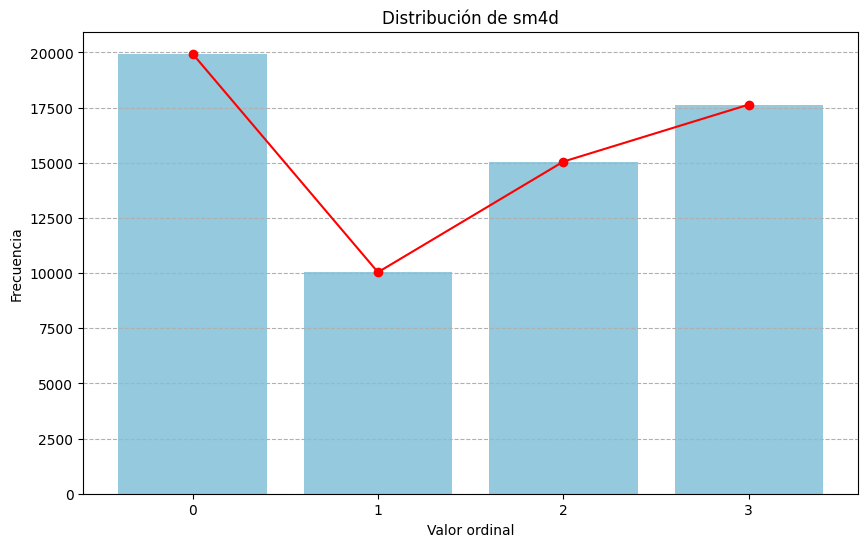

In [25]:
visdist(df, 'sm4d')

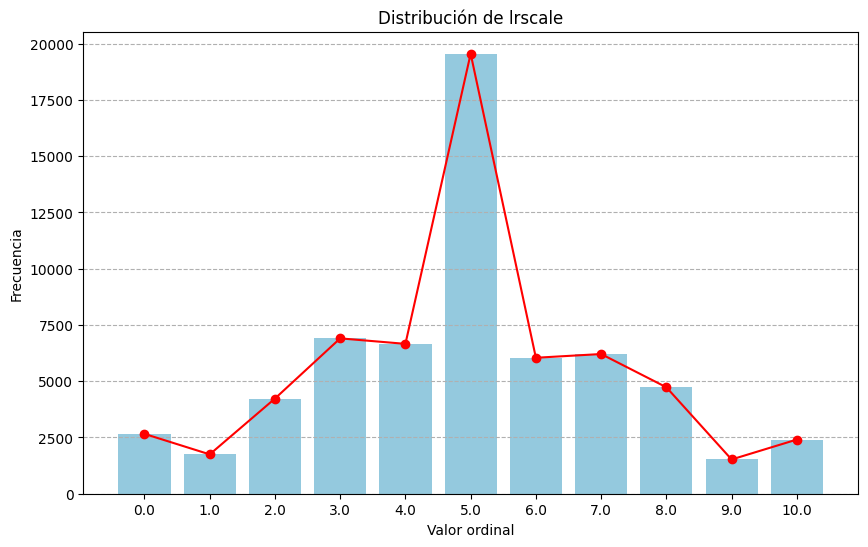

In [26]:
visdist(df, 'lrscale')

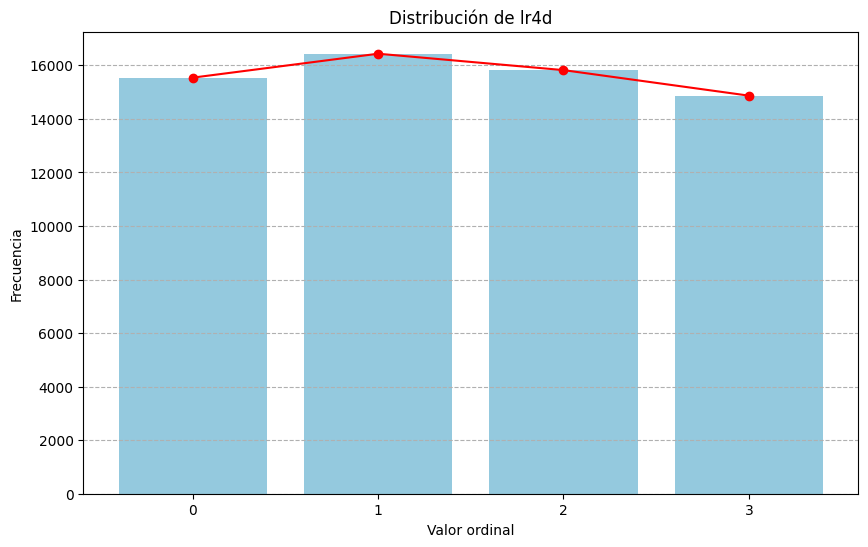

lr4d
1    16434
2    15822
0    15540
3    14868
Name: count, dtype: int64

In [27]:
ord10to4MidDense(df, 'lrscale', 'lr4d')
visdist(df, 'lr4d')
df['lr4d'].value_counts()

#Candidata a un modelo de clasificacion , muy balanceada la variable target.

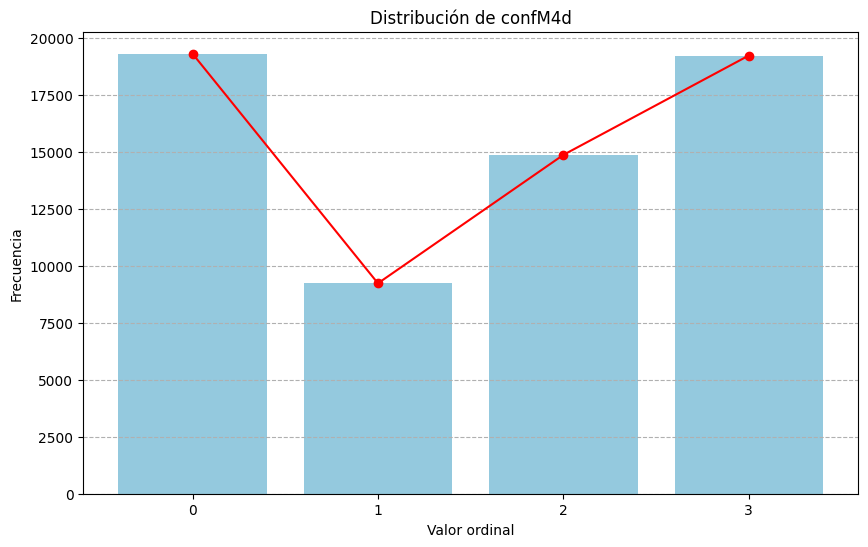

confM4d
0    19316
3    19236
2    14875
1     9237
Name: count, dtype: int64

In [28]:
ord10to4MidDense(df, 'confianza_promedio', 'confM4d')
visdist(df, 'confM4d')
df['confM4d'].value_counts()

In [29]:
def ord10to3NoMiDense(df, columna, nombre_categoria):


    
    percentil_33 = np.percentile(df[columna], 33.3)
    percentil_66 = np.percentile(df[columna], 66.6)

    
    df[nombre_categoria] = pd.cut(df[columna],
                                  bins=[-float('inf'), percentil_33, percentil_66, float('inf')],
                                  labels=[1, 2, 3],
                                  right=True,
                                  include_lowest=True)
    return df

ord10to3MidDense(df,'pplfair','pplfair3d')
ord10to3MidDense(df,'pplhlp','pplhlp3d')
ord10to3MidDense(df,'ppltrst','ppltrst3d')
ord10to3MidDense(df,'stfdem','stfdem3d')
ord10to3NoMiDense(df,'stfeco','stfeco3d')
ord10to3MidDense(df,'stfgov','stfgov3d')
ord10to3MidDense(df,'trstep','trstep3d')
ord10to3NoMiDense(df,'trstlgl','trstlgl3d')
binarizar_ponderado(df,'trstplc','trstplc2fc')
binarizar_ponderado(df,'trstplt','trstplt2fc')
ord10to3MidDense(df,'trstprl','trstprl3d')




,cntry,pplfair,pplhlp,ppltrst,lrscale,polintr,stfdem,stfeco,stfgov,trstep,...,pplhlp3d,ppltrst3d,stfdem3d,stfeco3d,stfgov3d,trstep3d,trstlgl3d,trstplc2fc,trstplt2fc,trstprl3d
0,Bélgica,4.0,5.0,5.0,5.0,2.0,7.0,5.0,5.0,5.0,...,2,2,1,2,0,0,1,1,1,0
1,Bélgica,8.0,8.0,10.0,5.0,4.0,5.0,7.0,5.0,2.0,...,2,2,0,3,0,0,1,1,1,2
2,Bélgica,7.0,8.0,7.0,5.0,3.0,6.0,6.0,4.0,7.0,...,2,0,2,3,2,2,3,1,0,1
3,Bélgica,3.0,8.0,0.0,6.0,2.0,7.0,5.0,5.0,7.0,...,2,0,2,2,0,2,2,1,0,2
4,Bélgica,5.0,8.0,6.0,8.0,2.0,9.0,8.0,4.0,8.0,...,2,2,2,3,2,2,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62659,Eslovaquia,3.0,4.0,2.0,3.0,2.0,4.0,3.0,3.0,3.0,...,0,0,0,1,2,2,1,0,1,2
62660,Eslovaquia,8.0,8.0,4.0,2.0,3.0,2.0,2.0,2.0,8.0,...,2,2,0,1,2,2,1,1,1,1
62661,Eslovaquia,5.0,5.0,5.0,7.0,1.0,5.0,3.0,5.0,9.0,...,2,2,2,1,2,2,2,0,1,2
62662,Eslovaquia,7.0,4.0,7.0,0.0,2.0,8.0,6.0,7.0,7.0,...,0,1,2,3,2,2,3,0,1,0


Ya tenemos las variables target y predictores en varios formatos , habiendo respetado los pesos de la densidad
de muestras a lo largo de su rango. Ahora probaremos algun modelo de classificacion que trabaje bien con estas variables.


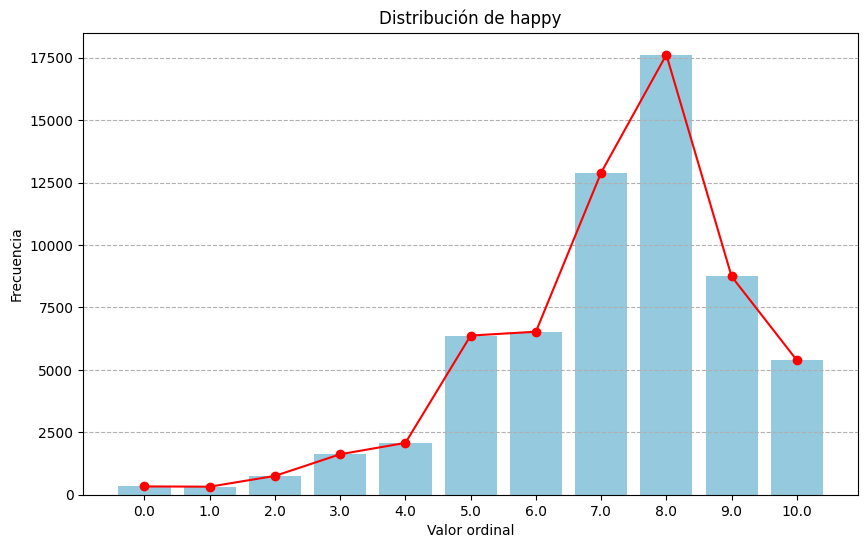

In [30]:
visdist(df, 'happy')

In [31]:
df.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/presplit/dfmodel.csv', index=False)